In [ ]:
!pip uninstall numpy --yes

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [ ]:
# Block 1: Instalasi Library
!pip install "xgboost>=2.0,<3.0" lightgbm catboost shap=='0.46.0'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.2
    Uninstalling xgboost-3.1.2:
      Successfully uninstalled xgboost-3.1.2
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0


In [ ]:
# Block 2: Impor Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
# Preprocessing dan Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Model
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
# Evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# XAI
import shap

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.46.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/SKR')

Mounted at /content/drive


In [ ]:
from gbt import param_grid_Cat
import numpy as np
import xgboost
import shap
print(np.__version__)
print(xgboost.__version__)
print(shap.__version__)

2.0.2
2.1.4
0.46.0


In [ ]:
import xgboost
import shap

# train an XGBoost model
X, y = shap.datasets.california()
model = xgboost.XGBRegressor().fit(X, y)

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

KeyboardInterrupt: 

In [ ]:
file_name = '/content/drive/MyDrive/SKR/WLALL2WS_GBT_td_K20.csv' # <-- GANTI NAMA FILE JIKA PERLU

try:
    data = pd.read_csv(file_name)
    print(f"Data '{file_name}' berhasil dimuat.")
    print("Shape data:", data.shape)
    print("\nContoh data (head):")
    print(data.head())

    print("\nTipe data (info):")
    data.info()

except FileNotFoundError:
    print(f"ERROR: File '{file_name}' tidak ditemukan.")
    print("Pastikan Anda sudah mengunggah file dan namanya sudah benar.")

Data '/content/drive/MyDrive/SKR/WLALL2WS_GBT_td_K20.csv' berhasil dimuat.
Shape data: (146561, 24)

Contoh data (head):
  segment     type  year  predicted_class    Topic1    Topic2    Topic3  \
0    high  leisure  2025                1  0.025623  0.095857  0.162542   
1    high  leisure  2025                0  0.613205  0.021342  0.020228   
2    high  leisure  2025                0  0.358419  0.018604  0.035030   
3    high  leisure  2025                1  0.015543  0.065592  0.051119   
4    high  leisure  2025                0  0.104416  0.013248  0.034735   

     Topic4    Topic5    Topic6  ...   Topic11   Topic12   Topic13   Topic14  \
0  0.008995  0.025082  0.026234  ...  0.132978  0.020630  0.037370  0.089464   
1  0.012055  0.011024  0.009055  ...  0.018709  0.035636  0.023061  0.007267   
2  0.041430  0.016832  0.024751  ...  0.035931  0.071660  0.047801  0.063241   
3  0.005546  0.369491  0.003925  ...  0.114764  0.018868  0.002166  0.056757   
4  0.065551  0.020610  0.021

# Data loading

In [ ]:
TARGET_COLUMN = 'predicted_class'

TOPIC_FEATURES = [col for col in data.columns if col.startswith('Topic')]
if not TOPIC_FEATURES:
    print("PERINGATAN: Tidak ada kolom 'Topic...' yang ditemukan. Pastikan file CSV Anda benar.")

FEATURES = TOPIC_FEATURES
X = data[FEATURES]
y = data[TARGET_COLUMN]

print(f"\nBentuk X (Hanya Fitur Topik): {X.shape}")
print(f"Bentuk y: {y.shape}")


Bentuk X (Hanya Fitur Topik): (146561, 20)
Bentuk y: (146561,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Dist y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Dist y_test:\n{y_test.value_counts(normalize=True)}")

Shape X_train: (117248, 20)
Shape X_test: (29313, 20)
Dist y_train:
predicted_class
0    0.759817
1    0.240183
Name: proportion, dtype: float64
Dist y_test:
predicted_class
0    0.759834
1    0.240166
Name: proportion, dtype: float64


# RF & MLP

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

RANDOM_STATE = 42
SCORING_METRIC = "f1"

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [20, 25, 35],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4, 8, 16],
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring=SCORING_METRIC,
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("\n--- Starting Grid Search for Random Forest ---")
grid_rf.fit(X_train, y_train)

print("\n--- Grid Search Complete ---")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best F1 Score (CV): {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n--- Random Forest Test Set Results ---")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy:  {accuracy_rf:.6f}")
print(f"Precision: {precision_rf:.6f}")
print(f"Recall:    {recall_rf:.6f}")
print(f"F1-Score:  {f1_rf:.6f}")



--- Starting Grid Search for Random Forest ---
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



--- Grid Search Complete ---
Best Parameters: {'bootstrap': False, 'max_depth': 35, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best F1 Score (CV): 0.8836

--- Random Forest Test Set Results ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     22273
           1       0.95      0.84      0.89      7040

    accuracy                           0.95     29313
   macro avg       0.95      0.91      0.93     29313
weighted avg       0.95      0.95      0.95     29313

Accuracy:  0.951387
Precision: 0.948268
Recall:    0.843608
F1-Score:  0.892881


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV

# --- Configuration ---
RANDOM_STATE = 42
EPOCHS = 200
BATCH_SIZE = 32
TEST_SIZE = 0.2
INPUT_SHAPE = X_train.shape[1]
SCORING_METRIC = "f1"

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

print(f"Shapes: X_train={X_train_np.shape}, y_train={y_train_np.shape}, X_test={X_test_np.shape}, y_test={y_test_np.shape}")
print(f"Input shape for MLP: {INPUT_SHAPE}")

mlp_base = MLPClassifier(
    activation='relu',
    solver='adam',
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

param_grid_mlp = {
    'hidden_layer_sizes': [(32, 32), (64, 32), (128, 64), (256, 128)],
    'alpha': [0.001, 0.01],                               # L2 regularization strength
    'learning_rate_init': [0.001, 0.0005],
}

# --- Grid Search Setup ---
grid_mlp = GridSearchCV(
    estimator=mlp_base,
    param_grid=param_grid_mlp,
    scoring=SCORING_METRIC,
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("\n--- Starting Grid Search for MLPClassifier ---")
grid_mlp.fit(X_train_np, y_train_np)

print("\n--- Grid Search Complete ---")
print(f"Best Parameters: {grid_mlp.best_params_}")
print(f"Best F1 Score (CV): {grid_mlp.best_score_:.4f}")

best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_np)

accuracy_sk = accuracy_score(y_test_np, y_pred_mlp)
precision_sk = precision_score(y_test_np, y_pred_mlp)
recall_sk = recall_score(y_test_np, y_pred_mlp)
f1_sk = f1_score(y_test_np, y_pred_mlp)

print("\n--- MLPClassifier Test Set Results ---")
print(classification_report(y_test_np, y_pred_mlp))
print(f"Accuracy:  {accuracy_sk:.6f}")
print(f"Precision: {precision_sk:.6f}")
print(f"Recall:    {recall_sk:.6f}")
print(f"F1-Score:  {f1_sk:.6f}")

Shapes: X_train=(117248, 20), y_train=(117248,), X_test=(29313, 20), y_test=(29313,)
Input shape for MLP: 20

--- Starting Grid Search for MLPClassifier ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits

--- Grid Search Complete ---
Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001}
Best F1 Score (CV): 0.8943

--- MLPClassifier Test Set Results ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     22273
           1       0.95      0.86      0.90      7040

    accuracy                           0.95     29313
   macro avg       0.95      0.92      0.94     29313
weighted avg       0.95      0.95      0.95     29313

Accuracy:  0.954082
Precision: 0.945122
Recall:    0.858665
F1-Score:  0.899821


In [ ]:
import numpy as np
import pandas as pd
import pickle
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

RANDOM_STATE = 42
EPOCHS = 200
BATCH_SIZE = 128
INPUT_SHAPE = X_train.shape[1]

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

print(f"Shapes: X_train={X_train_np.shape}, y_train={y_train_np.shape}, X_test={X_test_np.shape}, y_test={y_test_np.shape}")

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

print("\n--- Training MLPClassifier ---")
mlp_model.fit(X_train_np, y_train_np)

# --- Evaluate on Test Set ---
y_pred = mlp_model.predict(X_test_np)

accuracy_sk = accuracy_score(y_test_np, y_pred)
precision_sk = precision_score(y_test_np, y_pred)
recall_sk = recall_score(y_test_np, y_pred)
f1_sk = f1_score(y_test_np, y_pred)

print("\n--- MLPClassifier Test Set Results ---")
print(classification_report(y_test_np, y_pred))
print(f"Accuracy:  {accuracy_sk:.6f}")
print(f"Precision: {precision_sk:.6f}")
print(f"Recall:    {recall_sk:.6f}")
print(f"F1-Score:  {f1_sk:.6f}")

# --- Save Model to .pkl ---
model_path = "/content/drive/MyDrive/SKR/mlp_model_256_128.pkl"
with open(model_path, "wb") as f:
    pickle.dump(mlp_model, f)

print(f"\nModel saved to: {model_path}")


Shapes: X_train=(117248, 20), y_train=(117248,), X_test=(29313, 20), y_test=(29313,)

--- Training MLPClassifier ---

--- MLPClassifier Test Set Results ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     22273
           1       0.95      0.86      0.90      7040

    accuracy                           0.96     29313
   macro avg       0.95      0.92      0.94     29313
weighted avg       0.96      0.96      0.95     29313

Accuracy:  0.955481
Precision: 0.948397
Recall:    0.861506
F1-Score:  0.902866

Model saved to: /content/drive/MyDrive/SKR/mlp_model_256_128.pkl


In [ ]:
import pickle

with open('/content/drive/MyDrive/SKR/best_mlp.pkl', 'wb') as f:
    pickle.dump(best_mlp, f)
print("SHAP object saved to 'shap_values_class1.pkl'")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SKR/best_mlp.pkl'

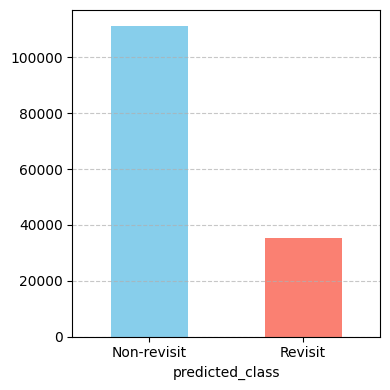

In [ ]:
import matplotlib.pyplot as plt

# Count occurrences of each predicted_class
class_counts = data['predicted_class'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(4, 4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# plt.title('Predicted Class Distribution')
# plt.xlabel('Revisit Intention')
# plt.ylabel('Count')

# Rename x-axis tick labels
plt.xticks([0, 1], ['Non-revisit', 'Revisit'], rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('predicted_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


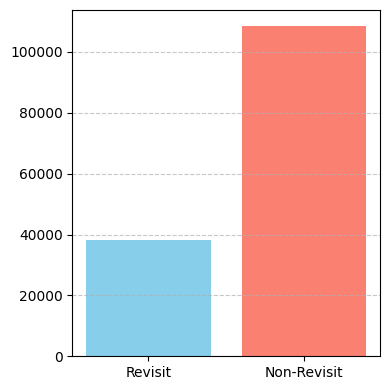

In [ ]:
import matplotlib.pyplot as plt

# Example data
labels = ['Class 1', 'Class 0']
values = [38201, 108360]

# Create bar chart
plt.figure(figsize=(4, 4))
plt.bar(labels, values, color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Revisit', 'Non-Revisit'], rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('predicted_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
class_counts

,count
predicted_class,
0,111360
1,35201


# GBT

In [ ]:
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('topics', 'passthrough', TOPIC_FEATURES)
    ],
    remainder='drop'
)

grid_searches = {}

# A. XGBoost
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

param_grid_xgb = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [5, 8, 10, 12],
    'model__learning_rate': [0.1, 0.01]
}

# B. LightGBM
pipeline_lgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(random_state=42))
])

param_grid_lgb = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [5, 8, 10, 12],
    'model__learning_rate': [0.1, 0.01]
}

# C. CatBoost
pipeline_cat = cb.CatBoostClassifier(
    random_state=42,
    verbose=0,
    eval_metric='F1'
)

param_grid_cat = {
    'iterations': [200, 300, 400, 500],
    'depth': [5, 8, 10, 12],
    'learning_rate': [0.1, 0.01]
}

SCORING_METRIC = 'f1'

# A. XGBoost
print("\nMemulai GridSearch untuk XGBoost...")
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=3, scoring=SCORING_METRIC, n_jobs=-1)
grid_xgb.fit(X_train, y_train)
grid_searches['XGBoost'] = grid_xgb
print(f"Best params: {grid_xgb.best_params_}")

# B. LightGBM
print("\nMemulai GridSearch untuk LightGBM...")
grid_lgb = GridSearchCV(pipeline_lgb, param_grid_lgb, cv=3, scoring=SCORING_METRIC, n_jobs=-1)
grid_lgb.fit(X_train, y_train)
grid_searches['LightGBM'] = grid_lgb
print(f"Best params: {grid_lgb.best_params_}")

# # C. CatBoost
print("\nMemulai GridSearch untuk CatBoost...")
grid_cat = GridSearchCV(pipeline_cat, param_grid_cat, cv=3, scoring=SCORING_METRIC, n_jobs=-1)
grid_cat.fit(X_train, y_train)
grid_searches['CatBoost'] = grid_cat
print(f"Best params: {grid_cat.best_params_}")



Memulai GridSearch untuk XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [03:10:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best params: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 500}

Memulai GridSearch untuk LightGBM...
[LightGBM] [Info] Number of positive: 28161, number of negative: 89087
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 117248, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240183 -> initscore=-1.151675
[LightGBM] [Info] Start training from score -1.151675
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 500}

Memulai GridSearch untuk CatBoost...
Best params: {'depth': 10, 'iterations': 500, 'learning_rate': 0.1}


In [ ]:
results = {}
best_f1 = -1
best_model_name = ""
best_model_estimator = None

print("--- Hasil Evaluasi pada Test Set ---")

for model_name, grid_search in grid_searches.items():
    print(f"\n===== {model_name} =====")
    best_estimator = grid_search.best_estimator_
    y_pred = best_estimator.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[model_name] = {'F1': f1, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall}

    print(classification_report(y_test, y_pred))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_name = model_name
        best_model_estimator = best_estimator

print("\n--- Ringkasan Performa Model ---")
results_df = pd.DataFrame(results).T.sort_values(by='F1', ascending=False)
print(results_df)

import joblib

model_filename = f"/content/drive/MyDrive/SKR/best_model_{best_model_name}.pkl"
joblib.dump(best_model_estimator, model_filename)

print(f"\nModel Kinerja Terbaik (berdasarkan F1-Score) adalah: {best_model_name}")

--- Hasil Evaluasi pada Test Set ---

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22273
           1       0.95      0.89      0.92      7040

    accuracy                           0.96     29313
   macro avg       0.96      0.94      0.95     29313
weighted avg       0.96      0.96      0.96     29313

Accuracy: 0.9640
Precision: 0.9539
Recall: 0.8933
F1-Score: 0.9226

--- Ringkasan Performa Model ---
               F1  Accuracy  Precision    Recall
XGBoost  0.922614  0.964009    0.95389  0.893324

Model Kinerja Terbaik (berdasarkan F1-Score) adalah: XGBoost
Model ini akan digunakan untuk analisis SHAP.


In [ ]:
import pandas as pd
import joblib

results = {}
best_f1 = -1
best_model_name = ""
best_model_estimator = None

for model_name, grid_search in grid_searches.items():
    best_estimator = grid_search.best_estimator_
    y_pred = best_estimator.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[model_name] = {'F1': f1, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall}

    if f1 > best_f1:
        best_f1 = f1
        best_model_name = model_name
        best_model_estimator = best_estimator

print("\n--- Ringkasan Performa Model ---")
results_df = pd.DataFrame(results).T.sort_values(by='F1', ascending=False)
print(results_df)

model_filename = f"/content/drive/MyDrive/SKR/best_model_{best_model_name}.pkl"
joblib.dump(best_model_estimator, model_filename) # Commented out to avoid errors

print(f"\nModel Kinerja Terbaik (berdasarkan F1-Score) adalah: {best_model_name}")



--- Ringkasan Performa Model ---
                F1  Accuracy  Precision    Recall
XGBoost   0.922614  0.964009   0.953890  0.893324
CatBoost  0.912439  0.959608   0.951712  0.876278
LightGBM  0.909616  0.958346   0.949760  0.872727

Model Kinerja Terbaik (berdasarkan F1-Score) adalah: XGBoost


In [ ]:
import joblib
model = joblib.load("/content/drive/MyDrive/SKR/best_model_XGBoost.pkl")
params = model.get_params()
print(params)


{'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('topics', 'passthrough',
                                 ['Topic1', 'Topic2', 'Topic3', 'Topic4',
                                  'Topic5', 'Topic6', 'Topic7', 'Topic8',
                                  'Topic9', 'Topic10', 'Topic11', 'Topic12',
                                  'Topic13', 'Topic14', 'Topic15', 'Topic16',
                                  'Topic17', 'Topic18', 'Topic19',
                                  'Topic20'])])), ('model', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
    

# SHAP

Memulai analisis SHAP untuk model: LightGBM...
Menghitung SHAP values... (ini mungkin perlu waktu)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


...Selesai dalam 26.20 detik.

Menampilkan SHAP Summary Plot (Bar)...


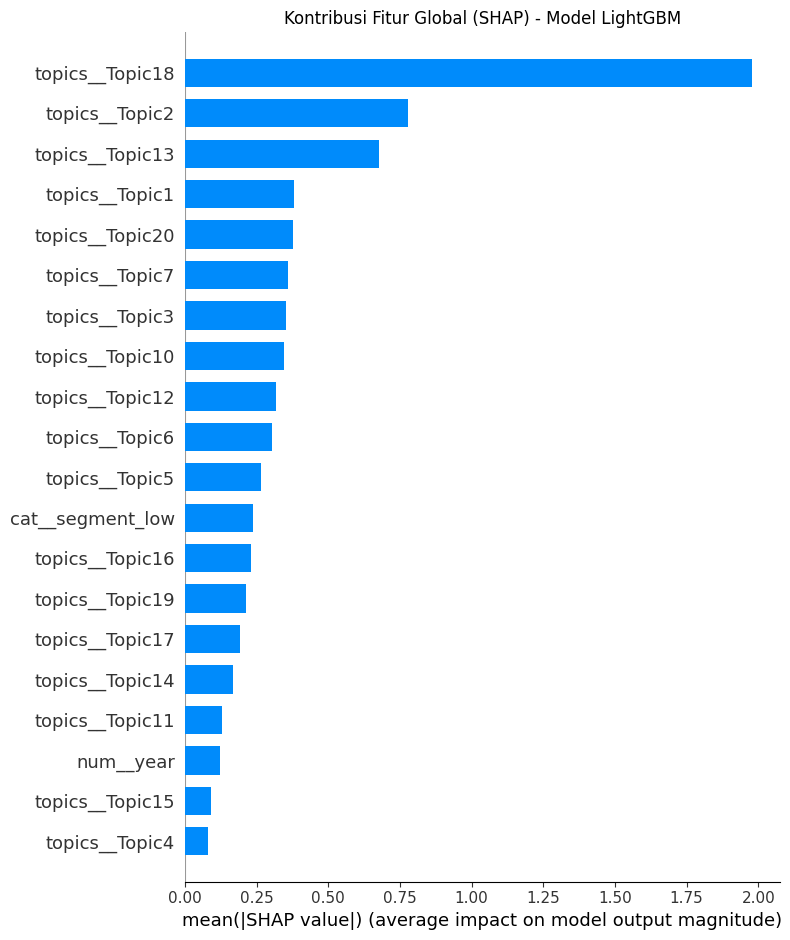


Menampilkan SHAP Summary Plot (Beeswarm)...


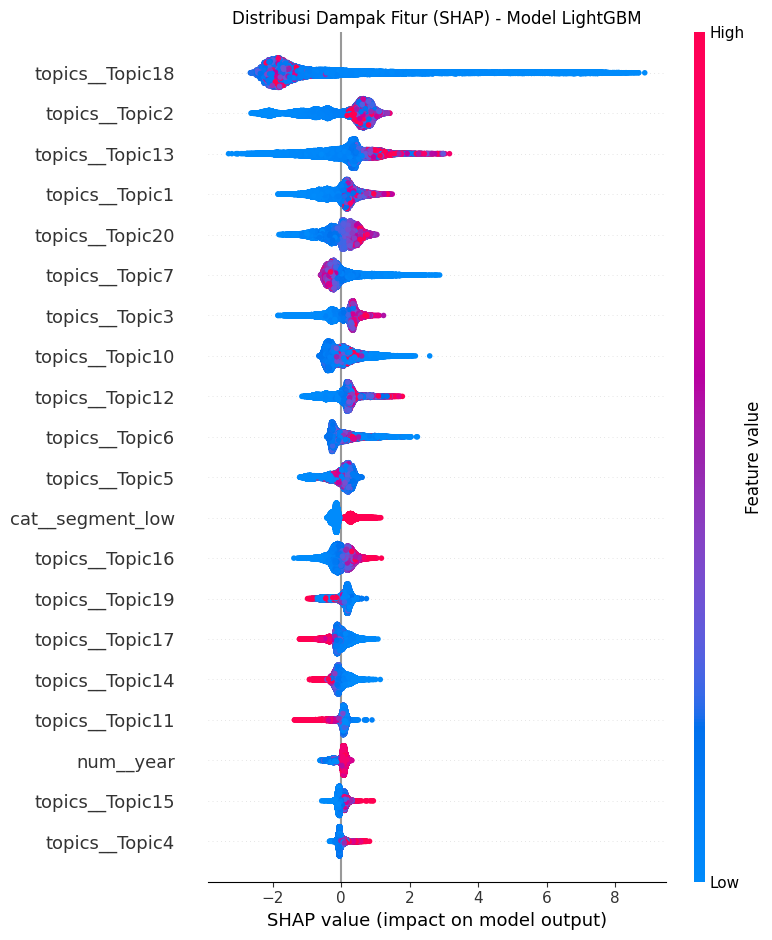

Analisis SHAP selesai. Gambar plot telah disimpan sebagai 'shap_summary_..._LightGBM.png'

Menampilkan SHAP Dependence Plot untuk fitur terpenting: 'topics__Topic18'


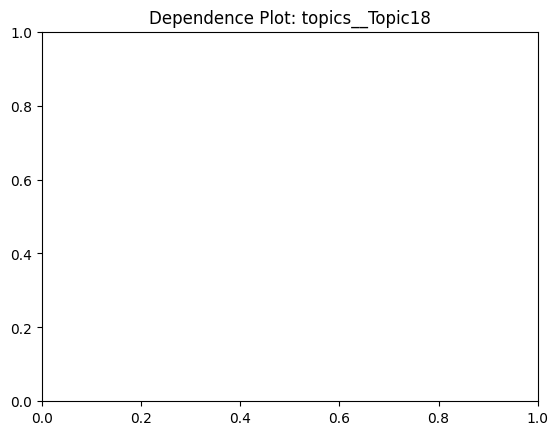

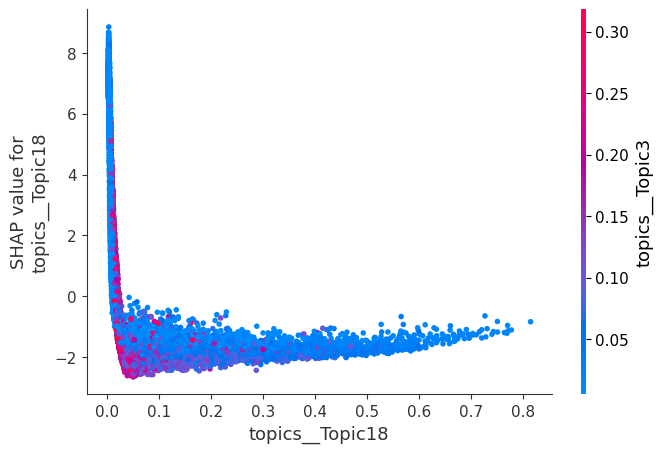

In [ ]:
print(f"Memulai analisis SHAP untuk model: {best_model_name}...")
if best_model_name == 'CatBoost':
    X_train_shap = X_train
    X_test_shap = X_test
    explainer = shap.TreeExplainer(best_model_estimator)

else:
    preprocessor_pipeline = best_model_estimator.named_steps['preprocessor']

    try:
        feature_names = preprocessor_pipeline.get_feature_names_out()
    except AttributeError:
        ohe_features = preprocessor_pipeline.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COVARIATES)
        feature_names = list(ohe_features) + NUMERICAL_COVARIATES + TOPIC_FEATURES

    X_train_transformed = preprocessor_pipeline.transform(X_train)
    X_test_transformed = preprocessor_pipeline.transform(X_test)

    X_train_shap = pd.DataFrame(X_train_transformed, columns=feature_names)
    X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

    model_shap = best_model_estimator.named_steps['model']
    explainer = shap.TreeExplainer(model_shap)


print("Menghitung SHAP values... (ini mungkin perlu waktu)")
start_time = time.time()
shap_values = explainer.shap_values(X_test_shap)
print(f"...Selesai dalam {time.time() - start_time:.2f} detik.")

# A. SHAP Summary Plot (Global Importance)
print("\nMenampilkan SHAP Summary Plot (Bar)...")
plt.title(f"Kontribusi Fitur Global (SHAP) - Model {best_model_name}")
shap.summary_plot(shap_values, X_test_shap, plot_type="bar", show=False)
plt.savefig(f"shap_summary_bar_{best_model_name}.png", bbox_inches='tight')
plt.show()


# B. SHAP Summary Plot (Beeswarm)
print("\nMenampilkan SHAP Summary Plot (Beeswarm)...")
plt.title(f"Distribusi Dampak Fitur (SHAP) - Model {best_model_name}")
shap.summary_plot(shap_values, X_test_shap, show=False)
plt.savefig(f"shap_summary_beeswarm_{best_model_name}.png", bbox_inches='tight')
plt.show()

print(f"Analisis SHAP selesai. Gambar plot telah disimpan sebagai 'shap_summary_..._{best_model_name}.png'")

# Dependence Plot untuk fitur terpenting
try:
    global_shap_values = np.abs(shap_values).mean(0)
    if isinstance(global_shap_values, np.ndarray) and global_shap_values.ndim > 1:
        global_shap_values = global_shap_values.mean(0)

    feature_importance = pd.Series(global_shap_values, index=X_test_shap.columns)
    most_important_feature = feature_importance.idxmax()

except Exception as e:
    print(f"Error getting most important feature: {e}")
    most_important_feature = TOPIC_FEATURES[0] # Ambil topik pertama saja


print(f"\nMenampilkan SHAP Dependence Plot untuk fitur terpenting: '{most_important_feature}'")
plt.title(f"Dependence Plot: {most_important_feature}")
shap.dependence_plot(
    most_important_feature,
    shap_values,
    X_test_shap,
    interaction_index="auto",
    show=False
)
plt.savefig(f"shap_dependence_{most_important_feature}.png", bbox_inches='tight')
plt.show()

In [ ]:
df['type'].value_counts()

,count
type,
leisure,79502
business,67059


In [ ]:
import pandas as pd
import numpy as np
import pickle  # Added for loading the .pkl file
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set a consistent style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 7) # Default figure size

# ---
# Section 1 & 2: Load Pre-Calculated Data
# ---
print("--- Sections 1 & 2: Loading Pre-Calculated Data ---")
df = pd.read_csv('/content/drive/MyDrive/SKR/WLALL2WS_GBT_td_K20.csv')


# Define feature names and extract X, which is still needed for plots
feature_names = [f'Topic{i}' for i in range(1, 21)]
topic_names = feature_names
X = df[feature_names]

# == LOAD THE SHAP VALUES ==
# This replaces all of the XGBoost and SHAP calculation code.
shap_file_name = '/content/drive/MyDrive/SKR/shap_values_class1.pkl'
try:
    with open(shap_file_name, 'rb') as f:
        shap_values_class1 = pickle.load(f)
    print(f"Successfully loaded SHAP values from '{shap_file_name}'")

    # Quick check to make sure shapes match
    assert len(X) == len(shap_values_class1), \
        f"Data mismatch! DataFrame has {len(X)} rows but SHAP object has {len(shap_values_class1)}."

except FileNotFoundError:
    print(f"ERROR: File '{shap_file_name}' not found.")
    print("Please make sure the .pkl file is in the same directory.")
    # In a real script, you might want to stop execution here
    # For this example, we'll create a mock SHAP object to proceed
    print("Creating MOCK SHAP values to allow script to run...")
    mock_shap_values = np.random.rand(len(X), len(feature_names))
    mock_data = X.values
    shap_values_class1 = shap.Explanation(
        values=mock_shap_values,
        base_values=np.array([0.5] * len(X)),
        data=mock_data,
        feature_names=feature_names
    )
except Exception as e:
    print(f"An error occurred loading the pickle file: {e}")

# ---
# Section 3: Analysis for Research Question 1 (Bisnis vs. Liburan)
# ---
print("\n--- Section 3: Generating Artifacts for RQ1 ---")

# Get the indices for each segment
bisnis_indices = df[df['segment'] == 'Bisnis'].index
liburan_indices = df[df['segment'] == 'Liburan'].index

# Convert the pandas.Index to a simple list for slicing the SHAP object
bisnis_indices_list = bisnis_indices.tolist()
liburan_indices_list = liburan_indices.tolist()

# Get the data (X) for each segment
X_bisnis = X.loc[bisnis_indices]
X_liburan = X.loc[liburan_indices]

# Filter SHAP values using the new list
shap_bisnis = shap_values_class1[bisnis_indices_list]
shap_liburan = shap_values_class1[liburan_indices_list]

# == Artifact 1A: Comparative Topic Prevalence ==
print("Generating Artifact 1A: Comparative Topic Prevalence (Bar Chart)...")
prevalence_bisnis = X_bisnis.mean()
prevalence_liburan = X_liburan.mean()

df_prevalence = pd.DataFrame({
    'Bisnis': prevalence_bisnis,
    'Liburan': prevalence_liburan
})

plt.figure(figsize=(12, 7))
df_prevalence.plot(kind='bar', ax=plt.gca())
plt.title('RQ1 (Artifact 1A): Mean Topic Prevalence by Travel Purpose', fontsize=16)
plt.ylabel('Mean Prevalence')
plt.xlabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Travel Purpose')
plt.tight_layout()
plt.savefig('rq1_prevalence_bar.png')
plt.close()
print("Saved: rq1_prevalence_bar.png")

# == Artifact 1B: Comparative Revisit Intention Drivers (SHAP) ==
print("Generating Artifact 1B: Comparative Revisit Intention Drivers (SHAP Bar Chart)...")
# We use the .values attribute of the sliced SHAP object
mean_abs_shap_bisnis = np.abs(shap_bisnis.values).mean(axis=0)
mean_abs_shap_liburan = np.abs(shap_liburan.values).mean(axis=0)

df_shap_impact = pd.DataFrame({
    'Bisnis Driver Impact': mean_abs_shap_bisnis,
    'Liburan Driver Impact': mean_abs_shap_liburan
}, index=topic_names)

# Sort by total impact to make the chart readable
df_shap_impact['Total Impact'] = df_shap_impact.sum(axis=1)
df_shap_impact = df_shap_impact.sort_values(by='Total Impact', ascending=True)

plt.figure(figsize=(10, 12)) # Taller figure for horizontal bar
df_shap_impact[['Bisnis Driver Impact', 'Liburan Driver Impact']].plot(kind='barh', ax=plt.gca())
plt.title('RQ1 (Artifact 1B): Key Drivers of Revisit Intention by Purpose', fontsize=16)
plt.xlabel('Mean Absolute SHAP Value (Impact on Model Output)')
plt.ylabel('Topic')
plt.legend(title='Travel Purpose')
plt.tight_layout()
plt.savefig('rq1_shap_impact_barh.png')
plt.close()
print("Saved: rq1_shap_impact_barh.png")

# == Artifact 1C: SHAP Dependence Plots for Top 3 Topics ==
print("Generating Artifact 1C: SHAP Dependence Plots for Top 3 Topics...")
top_3_topics = df_shap_impact.index[-3:].tolist() # Get top 3 from the sorted list

for topic in top_3_topics:
    # Create subplots, share the Y-axis for easier comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Plot 1: Business
    shap.dependence_plot(
        topic,
        shap_bisnis.values, # Pass the raw numpy array
        X_bisnis,
        ax=ax1,
        show=False,
        interaction_index=None
    )
    ax1.set_title(f'Impact of {topic} (Bisnis)')

    # Plot 2: Leisure
    shap.dependence_plot(
        topic,
        shap_liburan.values, # Pass the raw numpy array
        X_liburan,
        ax=ax2,
        show=False,
        interaction_index=None
    )
    ax2.set_title(f'Impact of {topic} (Liburan)')

    fig.suptitle(f'RQ1 (Artifact 1C): SHAP Dependence Plot for: {topic}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'rq1_dependence_{topic}.png')
    plt.close()
    print(f"Saved: rq1_dependence_{topic}.png")

# ---
# Section 4: Analysis for Research Question 2 (8 Segments)
# ---
print("\n--- Section 4: Generating Artifacts for RQ2 ---")

# Create the 8 micro-segment labels
df['micro_segment'] = df['segment'] + '_' + df['type']
micro_segments = sorted(df['micro_segment'].unique())
print(f"Created 8 micro-segments: {micro_segments}")

# == Artifact 2A: Heatmap of Topic Prevalence by 8 Segments ==
print("Generating Artifact 2A: Heatmap of Topic Prevalence...")
prevalence_heatmap_df = pd.DataFrame(index=topic_names, columns=micro_segments, dtype=float)

for seg in micro_segments:
    segment_data = df[df['micro_segment'] == seg]
    prevalence_heatmap_df[seg] = segment_data[topic_names].mean()

plt.figure(figsize=(14, 12))
sns.heatmap(
    prevalence_heatmap_df,
    annot=True,
    cmap='viridis',
    fmt='.3f',
    linewidths=0.5
)
plt.title('RQ2 (Artifact 2A): Mean Topic Prevalence Across 8 Segments', fontsize=16)
plt.xlabel('Micro-Segment (Purpose_Type)')
plt.ylabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('rq2_prevalence_heatmap.png')
plt.close()
print("Saved: rq2_prevalence_heatmap.png")

# == Artifact 2B: Heatmap of Revisit Intention Drivers (SHAP) by 8 Segments ==
print("Generating Artifact 2B: Heatmap of SHAP Impact...")
shap_impact_heatmap_df = pd.DataFrame(index=topic_names, columns=micro_segments, dtype=float)

for seg in micro_segments:
    segment_indices = df[df['micro_segment'] == seg].index
    if len(segment_indices) > 0:
        # Convert the pandas.Index to a simple list
        segment_indices_list = segment_indices.tolist()

        # Filter the SHAP object and get the .values
        segment_shap_values = shap_values_class1[segment_indices_list].values
        mean_abs_shap = np.abs(segment_shap_values).mean(axis=0)
        shap_impact_heatmap_df[seg] = mean_abs_shap
    else:
        shap_impact_heatmap_df[seg] = np.nan # Handle empty segments if any

plt.figure(figsize=(14, 12))
sns.heatmap(
    shap_impact_heatmap_df,
    annot=True,
    cmap='Reds', # 'Reds' is good for impact/importance
    fmt='.3f',
    linewidths=0.5
)
plt.title('RQ2 (Artifact 2B): Revisit Intention Drivers (Mean SHAP Impact) Across 8 Segments', fontsize=16)
plt.xlabel('Micro-Segment (Purpose_Type)')
plt.ylabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('rq2_shap_impact_heatmap.png')
plt.close()
print("Saved: rq2_shap_impact_heatmap.png")

print("\n--- Analysis Complete ---")
print("All artifacts for RQ1 and RQ2 have been generated and saved as PNG files.")

--- Sections 1 & 2: Loading Pre-Calculated Data ---
Successfully loaded SHAP values from '/content/drive/MyDrive/SKR/shap_values_class1.pkl'
An error occurred loading the pickle file: Data mismatch! DataFrame has 146561 rows but SHAP object has 29313.

--- Section 3: Generating Artifacts for RQ1 ---
Generating Artifact 1A: Comparative Topic Prevalence (Bar Chart)...
Saved: rq1_prevalence_bar.png
Generating Artifact 1B: Comparative Revisit Intention Drivers (SHAP Bar Chart)...


AttributeError: 'numpy.ndarray' object has no attribute 'values'